<font size="+3"><strong> Predicting Damage with Decision Tree</strong></font>

In [6]:
# ---------------------------------------------------------------
# 📊 Importing Essential Libraries
# ---------------------------------------------------------------

# Import warnings module to suppress unnecessary warnings
import warnings
# Ignore FutureWarning messages
warnings.simplefilter(action="ignore", category=FutureWarning)  

# Import libraries for visualization and data analysis
# For plotting charts and visualizations
import matplotlib.pyplot as plt   
# For data manipulation using DataFrames
import pandas as pd               

# Builds on matplotlib for easier statistical plotting
import seaborn as sns  

# Import an encoder to convert categorical features into ordinal numeric values
from category_encoders import OrdinalEncoder

# Import scikit-learn tools for model evaluation and train-test splitting
# To calculate accuracy of predictions
from sklearn.metrics import accuracy_score            
# To split data into training and testing sets
from sklearn.model_selection import train_test_split  

# Import scikit-learn pipeline utilities and models
# For chaining preprocessing and model steps
from sklearn.pipeline import Pipeline, make_pipeline 
# Decision tree model and visualization
from sklearn.tree import DecisionTreeClassifier, plot_tree  


# Prepare Data

## Import data

In [7]:
def wrangle(filepath):
    df=pd.read_csv(filepath) 

    df['damage_grade'] = df['damage_grade'].fillna(df['damage_grade'].mode()[0])
    # Identify leaky columns
    drop_cols = [col for col in df.columns if "post_eq" in col]
    
    # Create binary target
    df["damage_grade"] = df["damage_grade"].str[-1].astype(int)
    df["severe_damage"] = (df["damage_grade"] > 3).astype(int) 
    
    # Drop old target
    drop_cols.append("damage_grade")

    # Drop multicolinearity column
    drop_cols.append("count_floors_pre_eq")

    # Drop high categorical features
    drop_cols.append("building_id")

    # Drop columns
    df.drop(columns=drop_cols, inplace=True)

    return df


In [8]:
df = wrangle("../NepalEarhquakeDamage2015.csv")
df.head()

,district_id,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,severe_damage
0,12,9,288,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,0
1,12,15,364,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,1
2,12,20,384,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,0
3,12,20,312,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,0
4,12,30,308,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,0


## 🏚️ Creating a Binary Target and Dropping Post-Earthquake Features

In this step, we prepare our data for building a **binary classification model**.  
Currently, the target variable `"damage_grade"` has multiple categories representing the severity of damage to each building.

To simplify this into a binary problem, we'll create a new target column called **`"severe_damage"`**, where:
- Buildings with `"damage_grade"` **4 or above** will be labeled as **1 (Severe Damage)**
- Buildings with `"damage_grade"` **below 4** will be labeled as **0 (Not Severe)**

We’ll also remove the original `"damage_grade"` column to avoid data leakage.

Additionally, some features contain information collected **after** the earthquake — these are identified by the substring `"post_eq"`.  
Including them could leak future information into our model, so we'll drop all such columns within the `wrangle()` function.

### To implement this:
1. Update the `wrangle()` function to:
   - Drop all columns containing `"post_eq"`.
   - Create a new binary column `"severe_damage"`.
   - Drop the original `"damage_grade"` column.
2. Re-run all cells above to apply the updated data preparation steps.

This ensures our model is trained only on **pre-earthquake information** and learns to **classify buildings as severely or non-severely damaged**.


## Explore data

## 📊 Checking for Multicollinearity with a Correlation Heatmap

Before training a **linear model**, it’s important to check for **multicollinearity** —  
a condition where two or more features are highly correlated with each other.  
High correlations can cause instability in the model coefficients and reduce interpretability.

To detect this, we’ll create a **correlation heatmap** using the numerical features in our dataset.

### Steps:
1. Select only the **numerical features** from `df` (excluding the target column `"severe_damage"`).
2. Compute the **correlation matrix** between these features.
3. Visualize the results using a **seaborn heatmap** to identify highly correlated pairs.

This visualization helps us spot features that may provide redundant information and should potentially be removed or combined before modeling.


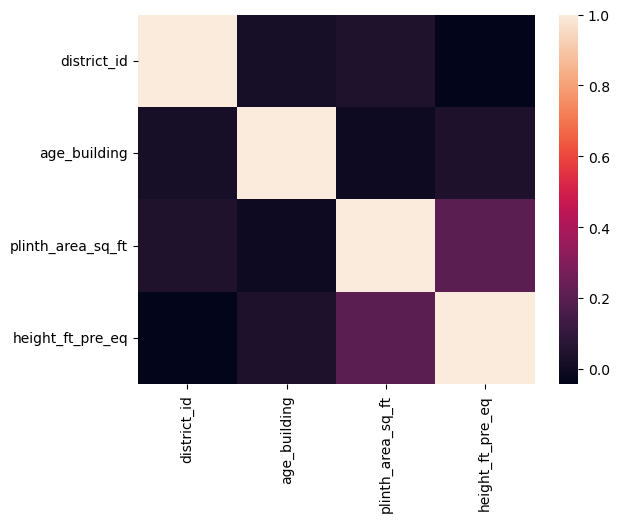

In [9]:
correlation = df.select_dtypes("number").drop(columns="severe_damage").corr()
sns.heatmap(correlation);

## Split


## 🏗️ Preparing Features and Target for Modeling

Before training our model, we need to separate the data into **features** and **target**:

- **Feature matrix (`X`)**: Contains all predictor variables used to predict damage.  
- **Target vector (`y`)**: Contains the binary target `"severe_damage"`.

---

### Splitting the Data
To evaluate our model’s performance properly, we’ll split the dataset into:

- **Training set**: 80% of the data, used to train the model  
- **Test set**: 20% of the data, used to evaluate the model on unseen data  

We’ll use a **randomized train-test split** and set a `random_state` to ensure the split is **reproducible**.  

This step ensures our model is trained on one subset of data while being evaluated on completely unseen examples, giving a reliable estimate of performance.

In [10]:
target = "severe_damage"
X = df.drop(columns=target)
y = df[target]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (609684, 11)
y_train shape: (609684,)
X_test shape: (152422, 11)
y_test shape: (152422,)


## 🔄 Creating a Validation Set

To properly evaluate and tune our Decision Tree model, we’ll split the **training data** into:

- **Training subset**: Used to fit the model  
- **Validation subset**: Used to evaluate the model during hyperparameter tuning  

### Key Points:
- The validation set should be **20% of the original training data**.  
- We use a **randomized train-test split** to ensure the split is representative.  
- Setting a **random_state** ensures the split is **reproducible**, so results are consistent each time we run the notebook.

This step allows us to **tune hyperparameters** like `max_depth` and check model performance without touching the test set.


In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,y_train,test_size=0.2,random_state=42
)

# Build Model

## Baseline

## 🎯 Calculating Baseline Accuracy

Before training any machine learning model, it’s important to establish a **baseline performance**.  

For a classification problem, the baseline accuracy is simply the proportion of the **majority class** in the target variable.  
This gives us a reference point — our model should **perform better than simply guessing the most frequent class**.

By calculating the baseline accuracy, we can:

- Understand how skewed our target classes are  
- Set a minimum performance threshold for the model  

Any model we build should aim to exceed this baseline to be considered useful.

In [12]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 2))

Baseline Accuracy: 0.6


## Iterate

## 🌳 Building a Decision Tree Pipeline

Now that our data is prepared, we’ll create a **machine learning pipeline** to train a model using a **Decision Tree**.  

### Pipeline Components:
1. **OrdinalEncoder**:  
   - Converts categorical features into numeric format by assigning an **integer to each category**.  
   - This is suitable for tree-based models, which can handle ordinal numeric values directly.

2. **DecisionTreeClassifier**:  
   - A non-linear, interpretable model that splits the data based on feature thresholds.  
   - Predicts whether a building will suffer **severe damage** based on its characteristics.

### Why a Pipeline?
- Ensures that **encoding and modeling steps** are applied consistently to both training and test sets.  
- Keeps the workflow **clean, reproducible, and easy to update** with different models or encoders.

Finally, we **fit the pipeline to the training data**, allowing the Decision Tree to learn the patterns and relationships in our dataset.


In [13]:
model = make_pipeline(
    OrdinalEncoder(),
    DecisionTreeClassifier(random_state=42)
)
model.fit(X_train,y_train)

Pipeline(steps=[('ordinalencoder',
                 OrdinalEncoder(cols=['land_surface_condition',
                                      'foundation_type', 'roof_type',
                                      'ground_floor_type', 'other_floor_type',
                                      'position', 'plan_configuration'],
                                mapping=[{'col': 'land_surface_condition',
                                          'data_type': dtype('O'),
                                          'mapping': Flat              1
Moderate slope    2
Steep slope       3
NaN              -2
dtype: int64},
                                         {'col': 'foundation_type',
                                          'data_type': dtype('O'...
                                          'data_type': dtype('O'),
                                          'mapping': Not attached       1
Attached-2 side    2
Attached-1 side    3
Attached-3 side    4
NaN                5
dtype: int64},
                                         {'col': 'plan_configuration',
                                          'data_type': dtype('O'),
                                          'mapping': Rectangular                         1
Square                              2
L-shape                             3
U-shape                             4
T-shape                             5
Multi-projected                     6
Others                              7
E-shape                             8
H-shape                             9
Building with Central Courtyard    10
NaN                                11
dtype: int64}])),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=42))])

## 📊 Evaluating and Exploring the Decision Tree Model

Once our Decision Tree pipeline is trained, we can evaluate its performance and explore its structure.

---

### 1️⃣ Training and Validation Accuracy
- Calculate **training accuracy** to see how well the model fits the training data.  
- Calculate **validation (test) accuracy** to evaluate how well the model generalizes to unseen data.  
- Comparing these scores can reveal if the model is **overfitting** (high training accuracy, low test accuracy) or **underfitting** (both scores low).

---

### 2️⃣ Examining Tree Depth
- Use the **`get_depth`** method on the `DecisionTreeClassifier` to see how deep the tree grew during training.  
- Tree depth indicates the complexity of the model:
  - **Shallow trees** → simpler model, may underfit  
  - **Deep trees** → complex model, may overfit

---

### 3️⃣ Exploring Max Depth Hyperparameter
- To find the optimal depth for the tree, we can define a range of **possible `max_depth` values**.  
- Here, we create `depth_hyperparams` ranging from **1 to 50 in steps of 2**.  
- This allows us to systematically experiment with different tree sizes and control overfitting.


In [15]:
acc_train = model.score(X_train,y_train)
acc_val = model.score(X_val,y_val)

print("Training Accuracy:", round(acc_train, 2))
print("Validation Accuracy:", round(acc_val, 2))

Training Accuracy: 0.97
Validation Accuracy: 0.97


In [16]:
tree_depth = model.named_steps["decisiontreeclassifier"].get_depth()
print("Tree Depth:", tree_depth)

Tree Depth: 57


In [17]:
depth_hyperparams = range(1,50,2)
depth_hyperparams

range(1, 50, 2)

## 🔧 Hyperparameter Tuning: Exploring Max Depth

Decision Trees are highly sensitive to their **max_depth** parameter, which controls how deep the tree can grow.  
A deeper tree can capture more patterns but may **overfit**, while a shallow tree may **underfit**.

### What We’ll Do:
- Train a **separate Decision Tree model for every value** in `depth_hyperparams`.  
- For each model, calculate:  
  - **Training accuracy** → How well the model fits the training subset  
  - **Validation accuracy** → How well the model generalizes to unseen validation data  
- Append these accuracy scores to two lists: `training_acc` and `validation_acc`.

This process allows us to **systematically explore** the effect of tree depth on model performance and select the optimal depth.


In [18]:
# Create empty lists for training and validation accuracy scores
training_acc = []
validation_acc = []

for d in depth_hyperparams:
    # Create model with `max_depth` of `d`
    test_model = make_pipeline(
        OrdinalEncoder(),
        DecisionTreeClassifier(max_depth=d,random_state=42)
    )
    # Fit model to training data
    test_model.fit(X_train, y_train)
    # Calculate training accuracy score and append to `training_acc`
    
    training_acc.append(test_model.score(X_train,y_train))
    # Calculate validation accuracy score and append to `training_acc`
    
    validation_acc.append(test_model.score(X_val,y_val))

print("Training Accuracy Scores:", training_acc[:3])
print("Validation Accuracy Scores:", validation_acc[:3])

Training Accuracy Scores: [0.7021058048537459, 0.7175625888011613, 0.7521009867820817]
Validation Accuracy Scores: [0.7019936524598768, 0.7183545601417125, 0.7529379925699337]


## 📈 Visualizing Training and Validation Accuracy vs. Tree Depth

After experimenting with different `max_depth` values, we can visualize how the tree depth affects model performance.

### Visualization Details:
- **X-axis**: `Max Depth` — the range of depths we tested (`depth_hyperparams`)  
- **Y-axis**: `Accuracy Score` — training and validation accuracy  
- **Lines**:  
  - **Training Accuracy** → Shows how well the model fits the training data  
  - **Validation Accuracy** → Shows how well the model generalizes to unseen data  
- **Legend**: Helps distinguish between training and validation performance  

This line chart helps us identify:
- **Overfitting**: Training accuracy is high but validation accuracy drops at deeper trees  
- **Underfitting**: Both accuracies are low for shallow trees  

By analyzing this plot, we can select the **optimal max_depth** that balances model complexity and generalization.


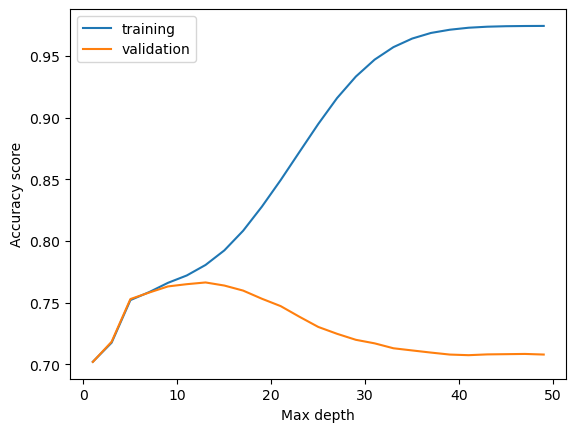

In [20]:
plt.plot(depth_hyperparams,training_acc,label="training")
plt.plot(depth_hyperparams,validation_acc,label="validation")
plt.xlabel("Max depth")
plt.ylabel("Accuracy score")
plt.legend();

## Evaluate

## 🎯 Selecting the Optimal Tree Depth and Evaluating on Test Data

Based on our training and validation accuracy visualization, we can identify the **max_depth** that yields the **highest validation accuracy**.  

### Steps:
1. **Select the best `max_depth`** from the validation results.  
2. **Retrain the original Decision Tree model** using this tuned max_depth on the full training data.  
3. **Evaluate the tuned model on the test set** to calculate the test accuracy score.

### Goals:
- Determine if the tuned tree **generalizes better** to unseen data  
- Assess whether this adjustment helps **resolve any overfitting** observed with deeper trees  
- Ensure that our model performs robustly and provides reliable predictions on new buildings.


In [21]:
test_acc = model.score(X_test,y_test)
print("Test Accuracy:", round(test_acc, 2))

Test Accuracy: 0.71


# Communicate

## 🌳 Visualizing the Decision Tree

To better understand how our Decision Tree makes predictions, we can use the **`plot_tree`** function from scikit-learn.  

### Key Points:
- The tree visualization shows the **decision logic** at each node:  
  - **Feature** used for the split  
  - **Threshold value**  
  - **Class distribution** and **predicted class**  
- This allows us to **interpret the model** and see which features are most influential in predicting severe damage.  
- Visualizing the tree is especially helpful for **communicating results** to stakeholders, as it provides an intuitive view of the decision-making process.


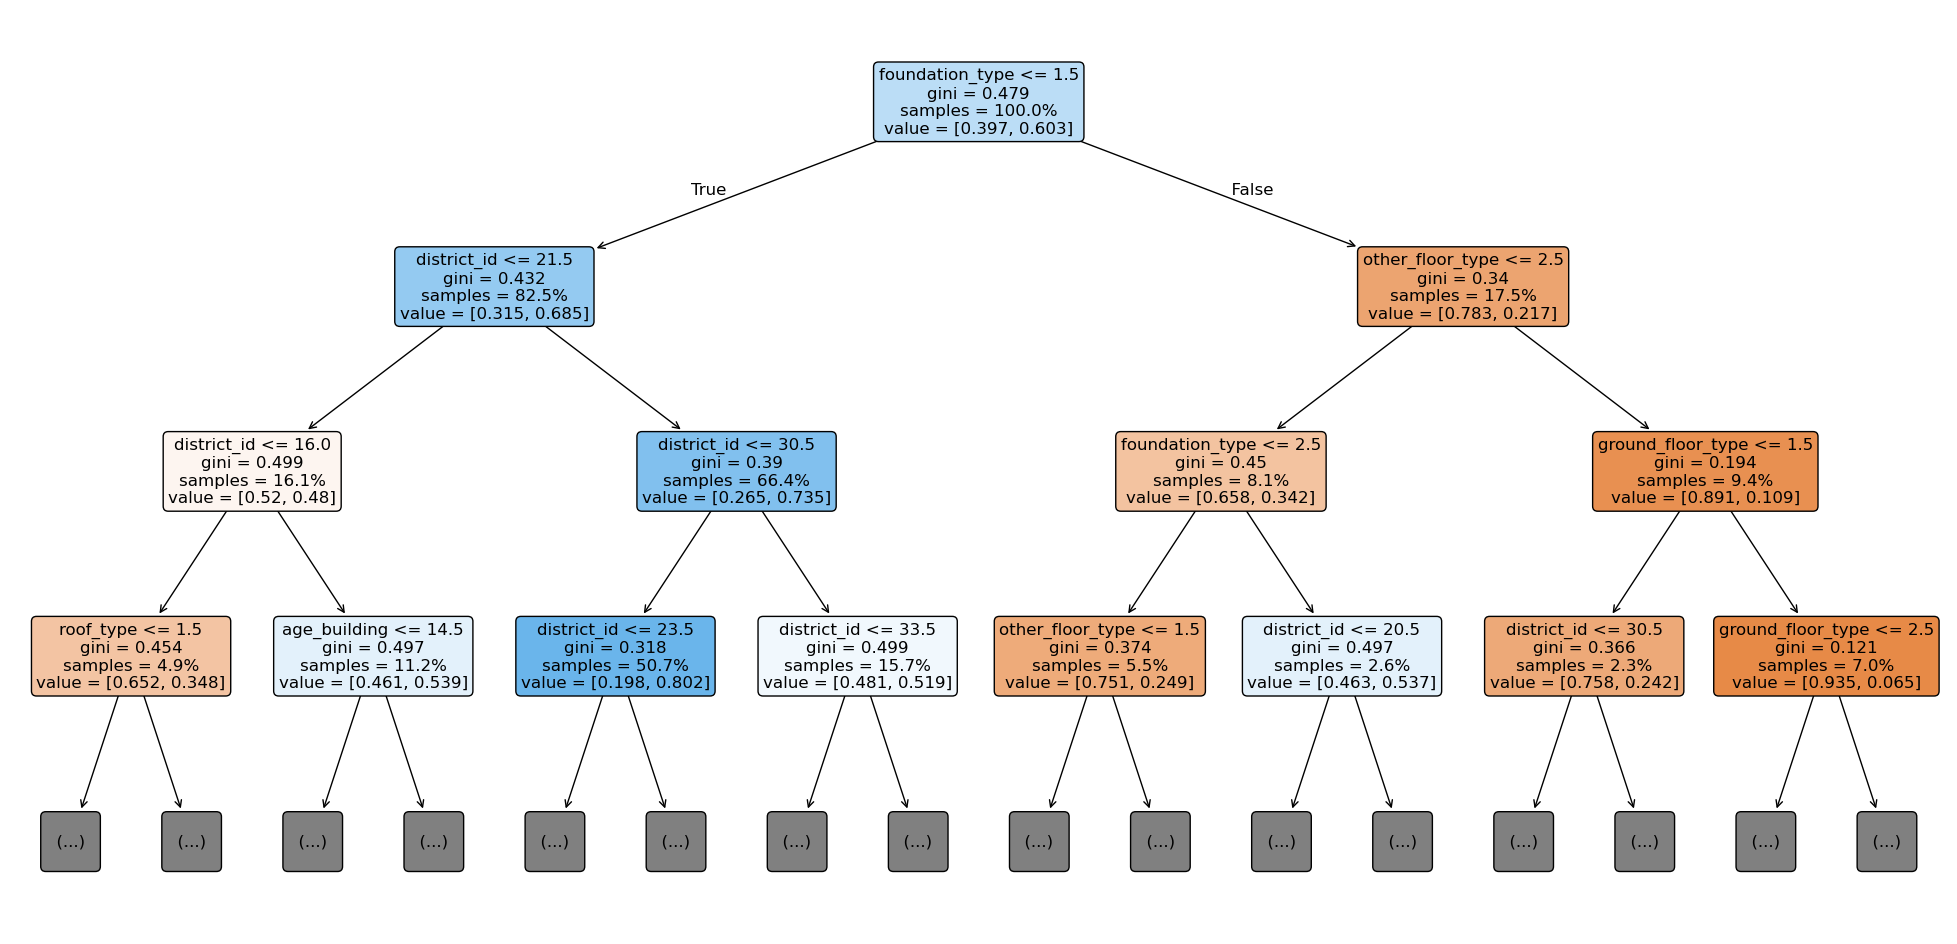

In [23]:
fig, ax = plt.subplots(figsize=(25, 12))
plot_tree(
    decision_tree = model.named_steps["decisiontreeclassifier"],
    feature_names = X_train.columns.to_list(),
    filled=True,  
    rounded=True,  
    proportion=True,  
    max_depth=3,  
    fontsize=12, 
    ax=ax,  
);

## 🔍 Analyzing Feature Importances

Decision Trees allow us to measure the **importance of each feature** in making predictions.  
We can extract these importances to understand which building characteristics contribute most to predicting severe damage.

### Steps:
1. **Assign feature names and importances**  
   - Feature names come from the column names in the training set  
   - Importances are accessed via the `feature_importances_` attribute of the trained `DecisionTreeClassifier`

2. **Create a pandas Series (`feat_imp`)**  
   - Index: feature names  
   - Values: feature importances  
   - Sort the Series from **smallest to largest** to easily visualize less and more important features

3. **Visualize with a horizontal bar chart**  
   - X-axis: `"Gini Importance"`  
   - Helps identify which features have the greatest influence on the model’s predictions

This step provides **interpretability** and insight into which building attributes are most critical in assessing earthquake damage.


In [25]:
features = X_train.columns
importances = model.named_steps["decisiontreeclassifier"].feature_importances_

print("Features:", features[:3])
print("Importances:", importances[:3])

Features: Index(['district_id', 'age_building', 'plinth_area_sq_ft'], dtype='object')
Importances: [0.16637135 0.18225501 0.27419849]


In [26]:
feat_imp = pd.Series(importances,index=features).sort_values()
feat_imp.head()

plan_configuration        0.009580
ground_floor_type         0.020075
roof_type                 0.021429
land_surface_condition    0.022711
position                  0.025783
dtype: float64

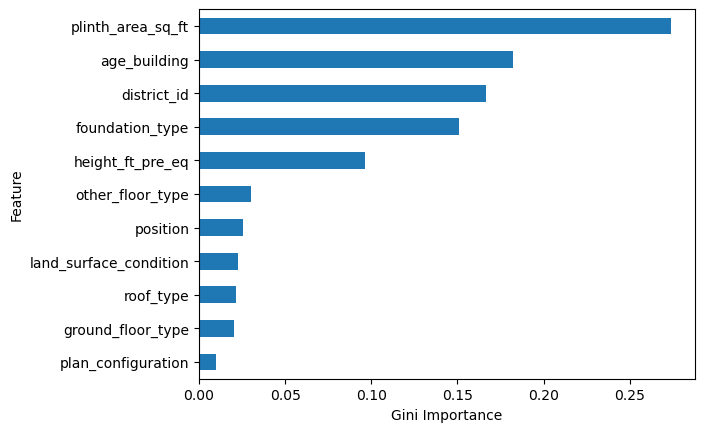

In [28]:
feat_imp.plot(kind="barh")
plt.xlabel("Gini Importance")
plt.ylabel("Feature");

## 🏁 Conclusion

In this part of the project, we explored **Decision Tree models** to predict severe earthquake damage.  

### Key Takeaways:
- We trained a **Decision Tree classifier** and tuned its `max_depth` to balance complexity and generalization.  
- Using a **validation set and accuracy visualization**, we were able to identify and reduce overfitting.  
- The **tree structure visualization** helped us interpret the model’s decision logic intuitively.  
- By analyzing **feature importances**, we discovered which building characteristics most strongly influence severe damage.  

This exercise demonstrates how **tree-based models** can provide both **accurate predictions** and **interpretable insights**, making them valuable tools for disaster risk assessment and prioritizing building safety efforts.
